In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("C:/Users/ADMIN/Downloads/titanic/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()
df.describe()
df.isnull().sum()
df.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [21]:
#Value counts for categorical data
df['Sex'].value_counts()
df['Pclass'].value_counts()
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

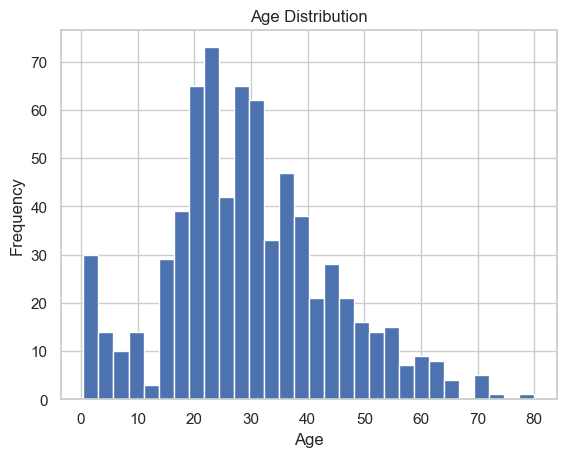

In [23]:
#Univariate analysis(single column)
df['Age'].hist(bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

#Observation
#Age distribution is right-skewed.#
#Majority of passengers are between# 20–40 years.
#There are some children and very few elderly passengers.

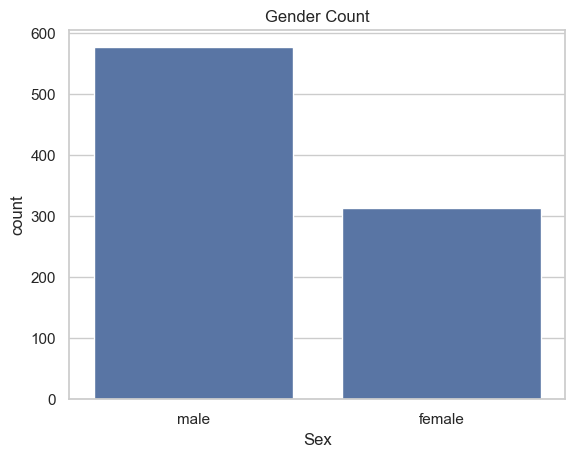

In [11]:
sns.countplot(x='Sex', data=df)
plt.title("Gender Count")
plt.show()


#Observation
#There are more males than females on the ship.

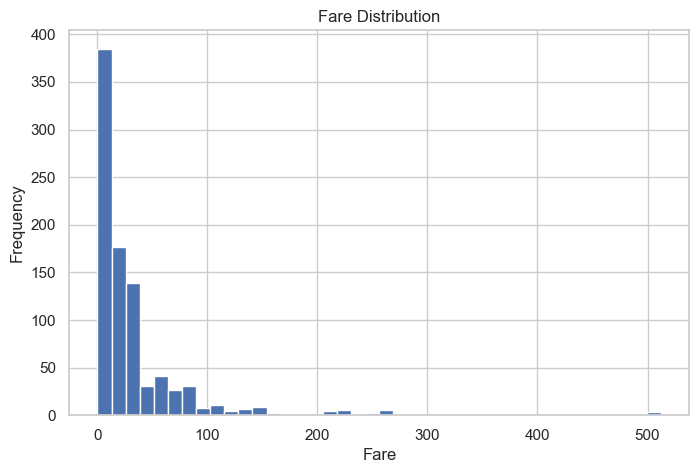

In [13]:
plt.figure(figsize=(8,5))
df['Fare'].hist(bins=40)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

#Observation
#Fare is highly right-skewed.
#Most tickets cost below 100.
#A few passengers paid extremely high fares, likely 1st class VIP passengers.

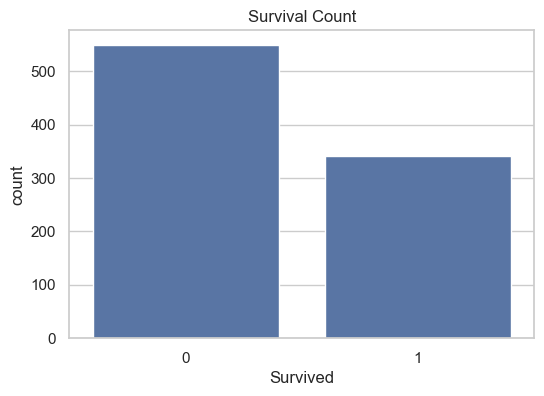

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

#Observation
#More people died (0) than survived (1).
#The dataset is imbalanced.

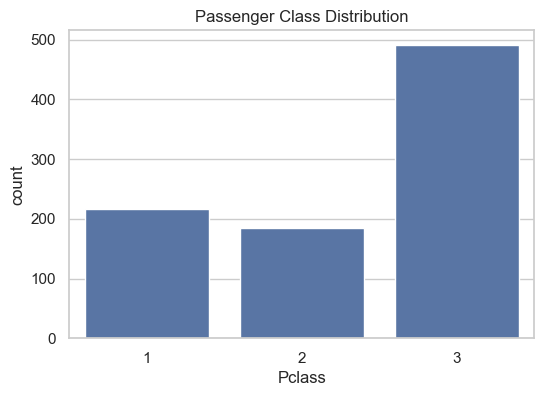

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', data=df)
plt.title("Passenger Class Distribution")
plt.show()

#Observation
#Most passengers were in 3rd class, fewer in 1st class, least in 2nd class.

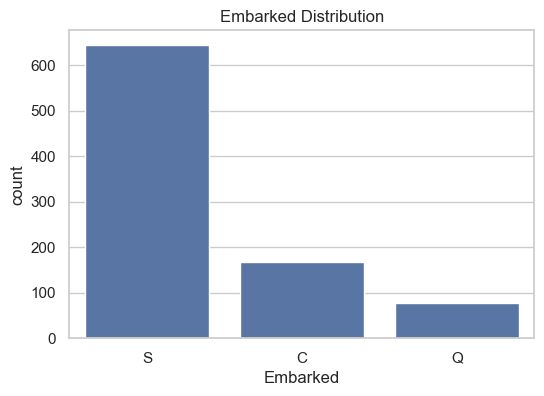

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x='Embarked', data=df)
plt.title("Embarked Distribution")
plt.show()

#Observation
#Most people boarded from Southampton (S).
#Cherbourg (C) has fewer passengers.
#Queenstown (Q) has the least.

### BIVARIATE ANALYSIS

<Axes: xlabel='Sex', ylabel='count'>

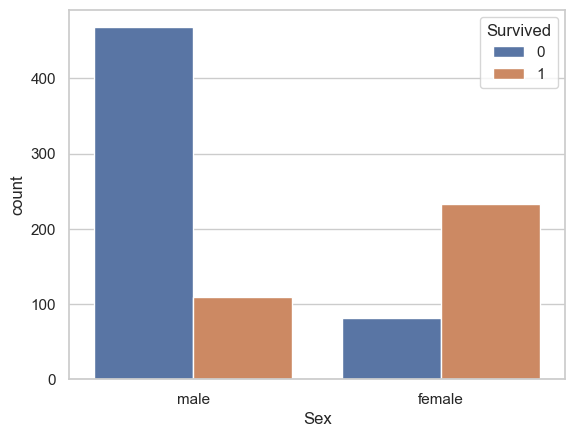

In [57]:
sns.countplot(x='Sex', hue='Survived', data=df)
#Observation (Survived vs Sex)
#More females survived than males.
#Survival rate for women is much higher.
#Gender was a strong factor in prioritizing rescue.

<Axes: xlabel='Pclass', ylabel='count'>

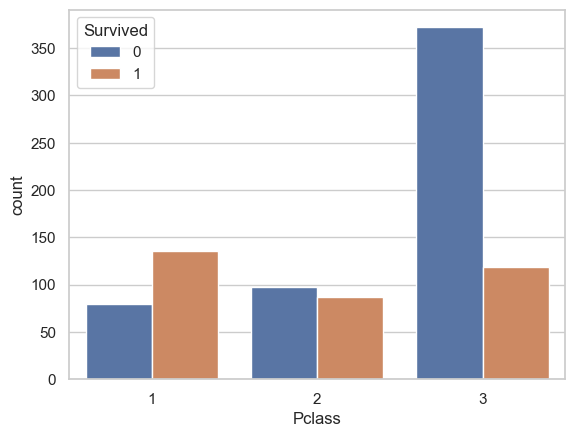

In [35]:
sns.countplot(x='Pclass', hue='Survived', data=df)
#Observation
#1st class passengers had the highest survival rate.
#3rd class had the lowest due to poorer access to boats.

<Axes: xlabel='Survived', ylabel='Fare'>

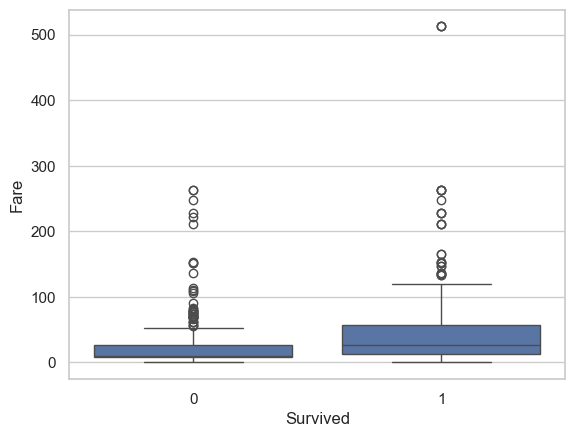

In [37]:
sns.boxplot(x='Survived', y='Fare', data=df)

#Observation
#Survivors generally paid higher fares.
#High-fare passengers were mostly 1st class → better rescue chances.

<Axes: xlabel='Survived', ylabel='Age'>

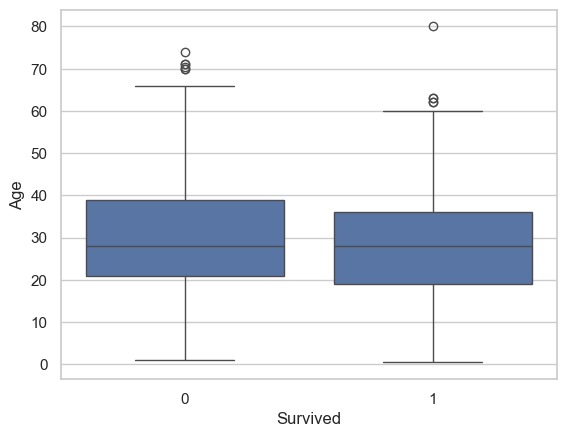

In [39]:
sns.boxplot(x='Survived', y='Age', data=df)

#Observation
#Children have a slightly higher chance of survival.
#Median age of survivors is lower than non-survivors.

### PAIRPLOT & CORRELATION

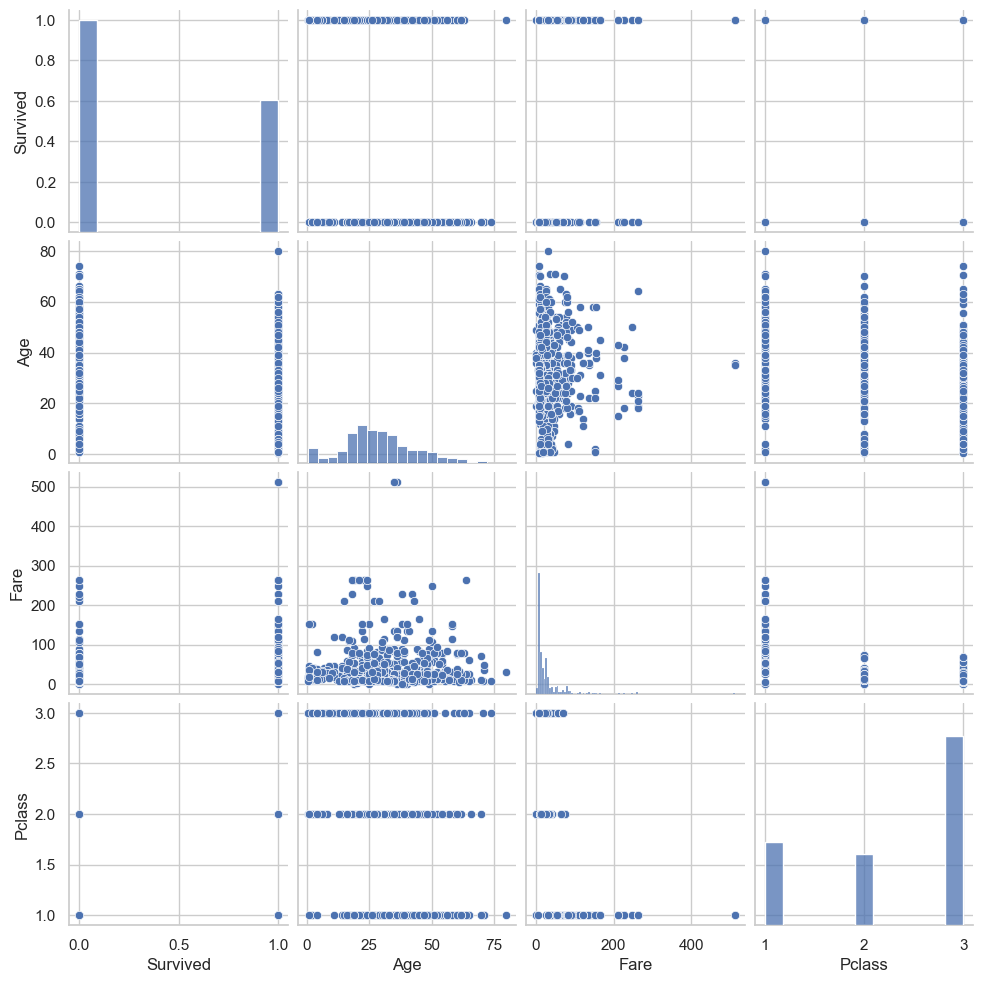

In [59]:
sns.pairplot(df[['Survived','Age','Fare','Pclass']])
plt.show()

#Observation
#Fare has a clear relationship with Class.
#Survival seems higher in low Pclass & higher Fare areas.

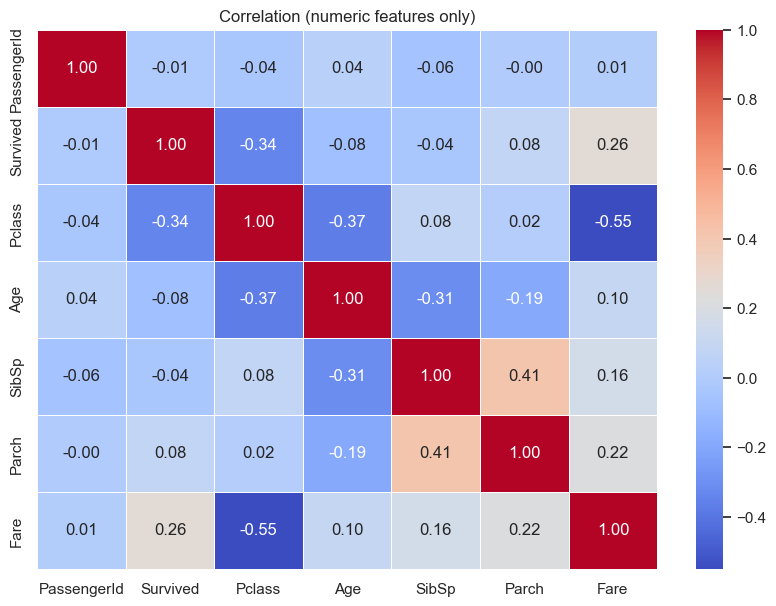

In [48]:
#HEATMAP
numeric_df = df.select_dtypes(include=[np.number])

# compute correlation
corr = numeric_df.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation (numeric features only)")
plt.show()

Observation

Fare and Pclass are negatively correlated (rich = 1st class).

Survived has:

Positive correlation with Fare

Negative correlation with Pclass

Age has very weak correlation with survival.

In [54]:
df.isnull().sum() 
#Age has missing values → can be filled with median.
#Cabin has many missing values → drop or ignore.
#Embarked has 2 missing values → fill with mode.

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Summary of Findings

Most passengers were adult males in 3rd class.

The ship carried more males than females.

Survival was highly dependent on gender — females survived more.

Class affected survival — 1st class survived the most, 3rd class the least.

Higher fares increased survival probability.

Age distribution shows most passengers were between 20–40 years.

Dataset contains missing values in Age, Cabin, and Embarked.

Fare data is right-skewed.